In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(color_codes=True)

from google.colab import files

from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn import metrics

import math

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = '/content/drive/MyDrive/ChronicKidneyDisease.csv'
df = pd.read_csv(file_path)
df

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,80.0,1.020,0.0,0.0,1.0,49.0,0.5,150.00,4.90,15.7,6700.0,4.90,0.0,0
396,70.0,1.025,0.0,0.0,1.0,31.0,1.2,141.00,3.50,16.5,7800.0,6.20,0.0,0
397,80.0,1.020,0.0,0.0,1.0,26.0,0.6,137.00,4.40,15.8,6600.0,5.40,0.0,0
398,60.0,1.025,0.0,0.0,1.0,50.0,1.0,135.00,4.90,14.2,7200.0,5.90,0.0,0


In [ ]:
df.replace({
    'normal': 0,
    'abnormal': 1,
    'no': 0,
    'yes': 1,
    'ckd': 1,
    'notckd': 0
}, inplace=True)

In [ ]:
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
print(df.info())

     Bp     Sg   Al   Su  Rbc    Bu   Sc     Sod   Pot  Hemo    Wbcc  Rbcc  \
0  80.0  1.020  1.0  0.0  1.0  36.0  1.2  137.53  4.63  15.4  7800.0  5.20   
1  50.0  1.020  4.0  0.0  1.0  18.0  0.8  137.53  4.63  11.3  6000.0  4.71   
2  80.0  1.010  2.0  3.0  1.0  53.0  1.8  137.53  4.63   9.6  7500.0  4.71   
3  70.0  1.005  4.0  0.0  1.0  56.0  3.8  111.00  2.50  11.2  6700.0  3.90   
4  80.0  1.010  2.0  0.0  1.0  26.0  1.4  137.53  4.63  11.6  7300.0  4.60   

   Htn  Class  
0  1.0      1  
1  0.0      1  
2  0.0      1  
3  1.0      1  
4  0.0      1  

Dataset Shape:
(400, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Bp      400 non-null    float64
 1   Sg      400 non-null    float64
 2   Al      400 non-null    float64
 3   Su      400 non-null    float64
 4   Rbc     400 non-null    float64
 5   Bu      400 non-null    f

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Bp       0
Sg       0
Al       0
Su       0
Rbc      0
Bu       0
Sc       0
Sod      0
Pot      0
Hemo     0
Wbcc     0
Rbcc     0
Htn      0
Class    0
dtype: int64


In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.2, random_state=42)

In [ ]:
model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("\nR2 Score:")
print(r2_score(y_test, y_pred))

print("\nMean Absolute Error:")
print(mean_absolute_error(y_test, y_pred))

print("\nMean Squared Error:")
print(mean_squared_error(y_test, y_pred))

print("\nRoot Mean Squared Error:")
print(math.sqrt(mean_squared_error(y_test, y_pred)))


R2 Score:
1.0

Mean Absolute Error:
0.0

Mean Squared Error:
0.0

Root Mean Squared Error:
0.0


In [ ]:
results = pd.DataFrame({
'Actual': y_test,
    'Predicted': y_pred
})

print("\nPrediction Comparison:")
print(results.head())


Prediction Comparison:
     Actual  Predicted
209       1        1.0
280       0        0.0
33        1        1.0
210       1        1.0
93        1        1.0


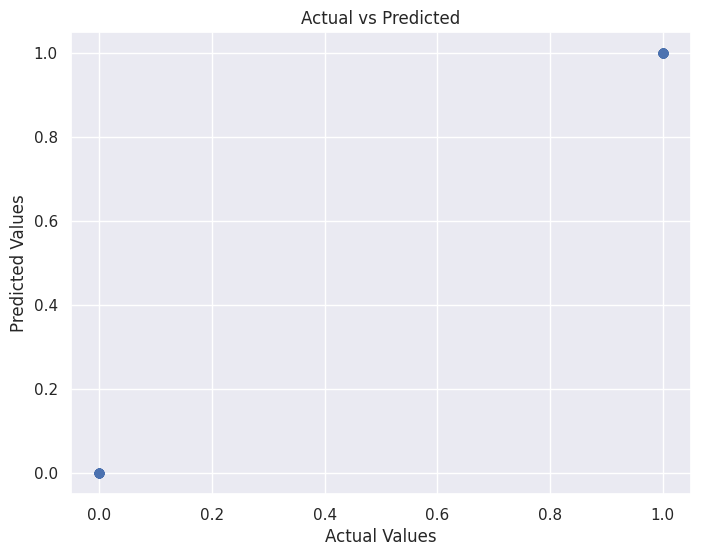

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

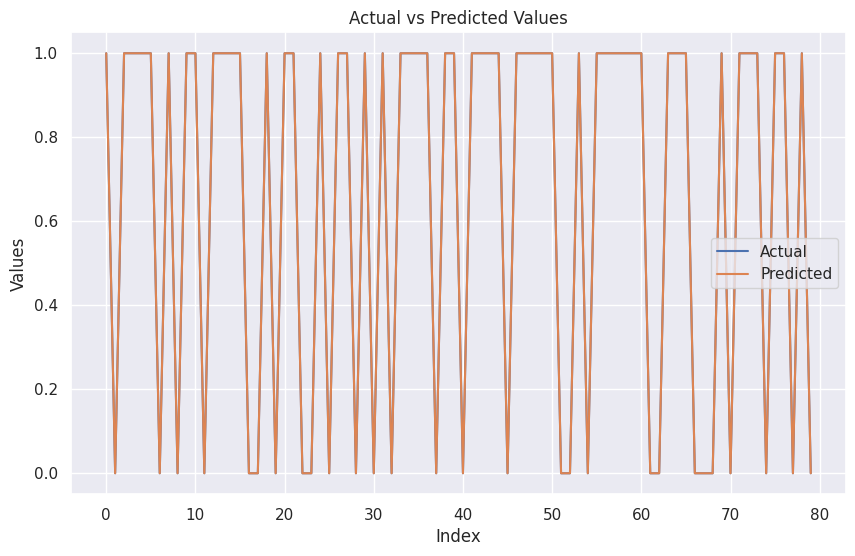

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.title("Actual vs Predicted Values")
plt.xlabel("Index")
plt.ylabel("Values")

plt.legend()

plt.show()

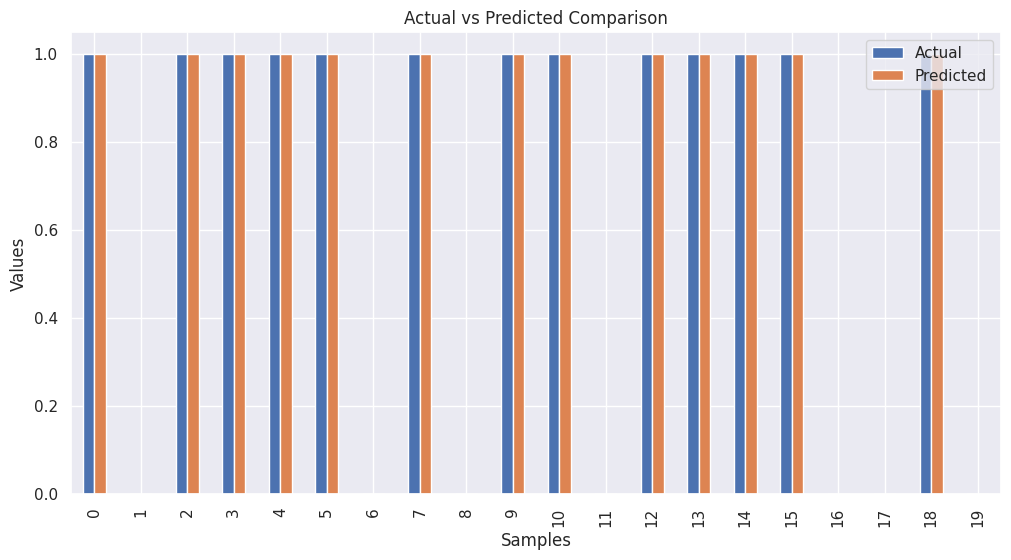

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values[:20],
    'Predicted': y_pred[:20]
})

comparison.plot(kind='bar', figsize=(12,6))

plt.title("Actual vs Predicted Comparison")
plt.xlabel("Samples")
plt.ylabel("Values")

plt.show()

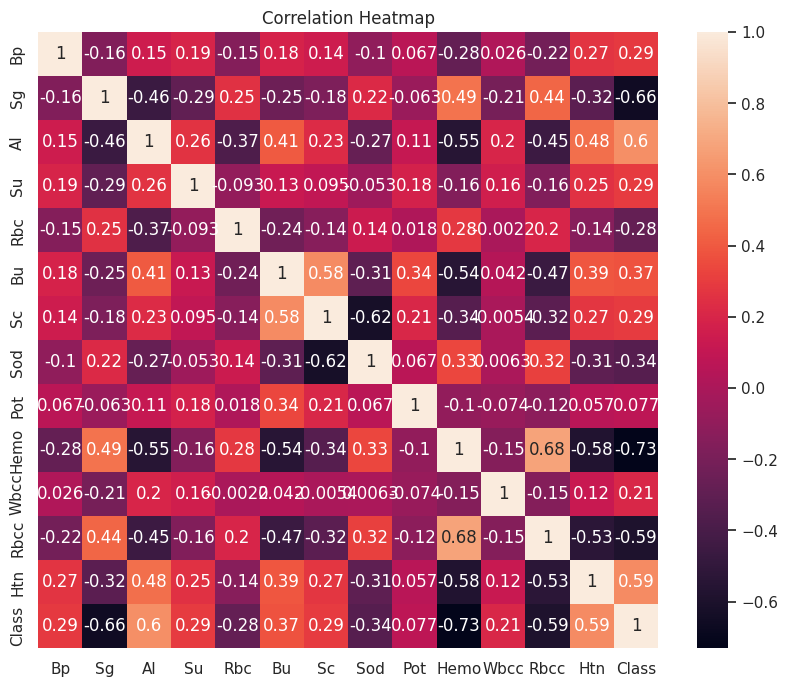

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

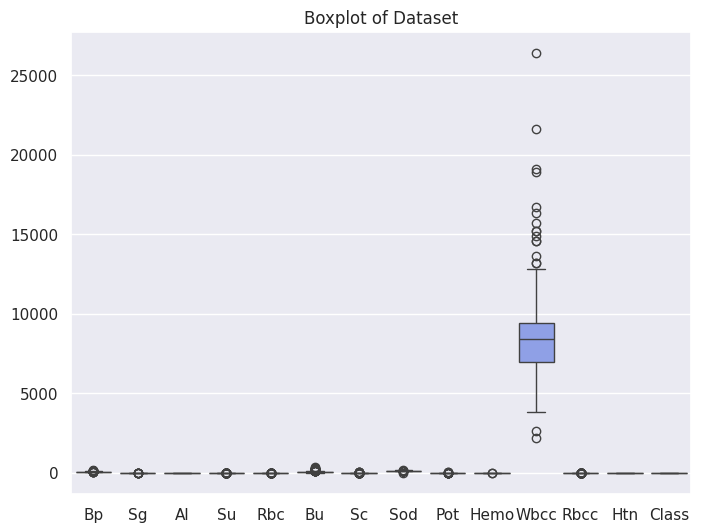

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df)

plt.title("Boxplot of Dataset")

plt.show()

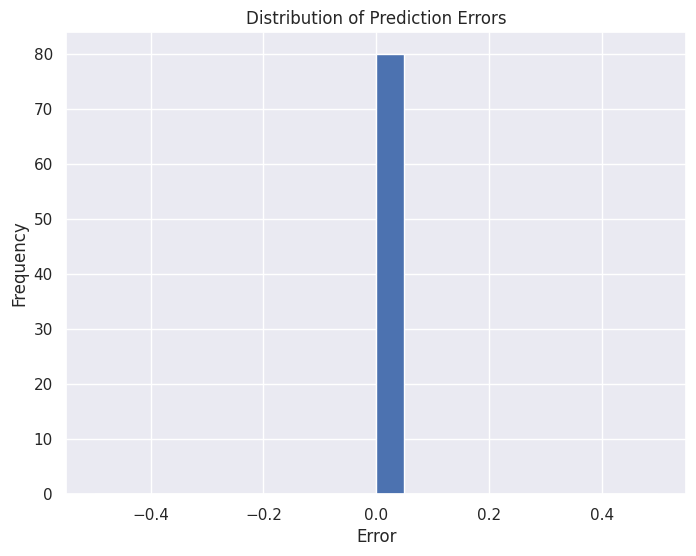

In [ ]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))

plt.hist(errors, bins=20)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df['Rbc'] = df['Rbc'].replace(['normal'], '0')
df['Rbc'] = df['Rbc'].replace(['abnormal'], '1')

df['Bp'] = df['Bp'].replace(['normal'], '0')
df['Bp'] = df['Bp'].replace(['abnormal'], '1')

df['Sg'] = df['Sg'].replace(['no'], '0')
df['Sg'] = df['Sg'].replace(['yes'], '1')

df['Al'] = df['Al'].replace(['no'], '0')
df['Al'] = df['Al'].replace(['yes'], '1')

df['Su'] = df['Su'].replace(['no'], '0')
df['Su'] = df['Su'].replace(['yes'], '1')

df['Rbc'] = df['Rbc'].replace(['no'], '0')
df['Rbc'] = df['Rbc'].replace(['yes'], '1')

df['Bu'] = df['Bu'].replace(['no'], '0')
df['Bu'] = df['Bu'].replace(['yes'], '1')

df['Sod'] = df['Sod'].replace(['no'], '0')
df['Sod'] = df['Sod'].replace(['yes'], '1')

df['Pot'] = df['Pot'].replace(['no'], '0')
df['Pot'] = df['Pot'].replace(['yes'], '1')

df['Hemo'] = df['Hemo'].replace(['notckd'], '0')
df['Hemo'] = df['Hemo'].replace(['ckd'], '1')

df['Wbcc'] = df['Wbcc'].replace(['notckd'], '0')
df['Wbcc'] = df['Wbcc'].replace(['ckd'], '1')

df['Class'] = df['Class'].replace(['notckd'], '0')
df['Class'] = df['Class'].replace(['ckd'], '1')

df.head()

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1
